In [14]:
## Import Jim-relatred stuff

import os
os.environ['JAX_PLATFORMS'] = 'cpu'
import pickle
import ast
import numpy as np

print("Importing JAX")
import jax
import jax.numpy as jnp
print("Importing JAX successful")

from jimgw.jim import Jim
from jimgw.single_event.detector import H1, L1, V1, GroundBased2G
from jimgw.single_event.likelihood import TransientLikelihoodFD, HeterodynedTransientLikelihoodFD
from jimgw.single_event.waveform import RippleIMRPhenomPv2
jax.config.update("jax_enable_x64", True)

Importing JAX
Importing JAX successful


In [15]:
from bilby.gw.detector import InterferometerList, PowerSpectralDensity, get_empty_interferometer
from bilby.gw import GravitationalWaveTransient, WaveformGenerator
from bilby.gw.source import lal_binary_black_hole
from bilby.gw.conversion import convert_to_lal_binary_black_hole_parameters

from gwpy.timeseries import TimeSeries

## Setup Bilby detectors

In [16]:
# Copy from the GW150914 example from Bilby.

# Note you can get trigger times using the gwosc package, e.g.:
# > from gwosc import datasets
# > datasets.event_gps("GW150914")
trigger_time = 1126259462.4
detectors = ["H1", "L1"]
sampling_frequency = 2048
maximum_frequency = sampling_frequency / 2
minimum_frequency = 20
roll_off = 0.4  # Roll off duration of tukey window in seconds, default is 0.4s
duration = 4  # Analysis segment duration
post_trigger_duration = 2  # Time between trigger time and end of segment
end_time = trigger_time + post_trigger_duration
start_time = end_time - duration

psd_duration = 32 * duration
psd_start_time = start_time - psd_duration
psd_end_time = start_time

# We now use gwpy to obtain analysis and psd data and create the ifo_list
ifo_list = InterferometerList([])
for det in detectors:
    ifo = get_empty_interferometer(det)
    data = TimeSeries.fetch_open_data(det, start_time, end_time)
    ifo.strain_data.set_from_gwpy_timeseries(data)

    psd_data = TimeSeries.fetch_open_data(det, psd_start_time, psd_end_time)
    psd_alpha = 2 * roll_off / duration
    psd = psd_data.psd(
        fftlength=duration, overlap=0, window=("tukey", psd_alpha), method="median"
    )
    ifo.power_spectral_density = PowerSpectralDensity(
        frequency_array=psd.frequencies.value, psd_array=psd.value
    )
    ifo.maximum_frequency = maximum_frequency
    ifo.minimum_frequency = minimum_frequency
    ifo_list.append(ifo)

## Now setup the Jim detectors

In [5]:
jim_ifos = [H1, L1]
for idx, ifo in enumerate(ifo_list):
    freq_mask = ifo.frequency_mask
    jim_ifos[idx].frequencies = ifo.frequency_array # * freq_mask
    jim_ifos[idx].psd = ifo.power_spectral_density_array * freq_mask
    jim_ifos[idx].data = ifo.frequency_domain_strain * freq_mask

(15, 1100)

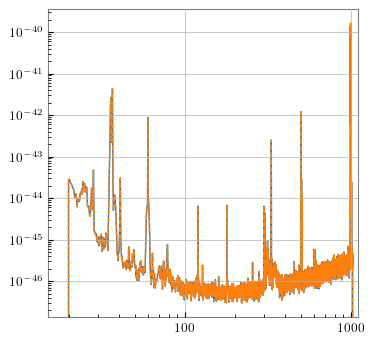

In [51]:
fa = ifo_list[0].frequency_array

fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.loglog(fa, H1.psd)
ax.loglog(fa, ifo_list[0].power_spectral_density_array * ifo_list[0].frequency_mask, ls='--')

ax.set_xlim(15, 1100)


/users/hin-wai.leong/.conda/envs/bilby_jim/lib/python3.10/site-packages/gwpy/plot/axes.py:78: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  return func(self, **kw)


(15, 1100)

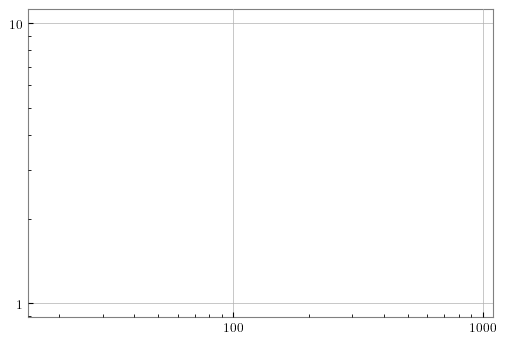

In [53]:
fa = ifo_list[0].frequency_array

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
mask = H1.psd > 0
# ax.loglog(fa,)
ax.loglog(fa[mask],  - 1 + H1.psd[mask] / ifo_list[0].power_spectral_density_array[mask], ls='--')
# ax.set_xscale('log')
ax.set_xlim(15, 1100)

## Setup waveform for both

In [6]:
reference_frequency = 20.

# Bilby waveform
bilby_waveform_generator = WaveformGenerator(
    duration=duration,
    sampling_frequency=sampling_frequency,
    start_time=start_time,
    frequency_domain_source_model=lal_binary_black_hole,
    parameter_conversion=convert_to_lal_binary_black_hole_parameters,
    waveform_arguments={
        "waveform_approximant": "IMRPhenomPv2",
        "reference_frequency": reference_frequency,
        "minimum_frequency": minimum_frequency,
        "maximum_frequency": maximum_frequency,},
)

# Jim waveforms
jim_waveform = RippleIMRPhenomPv2(f_ref=reference_frequency)

00:02 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


## Setup Likelihoods

In [7]:
bilby_likelihood = GravitationalWaveTransient(
    interferometers=ifo_list,
    waveform_generator=bilby_waveform_generator,
)

jim_likelihood = TransientLikelihoodFD(
    jim_ifos, waveform=jim_waveform, trigger_time=trigger_time,
    duration=duration, post_trigger_duration=post_trigger_duration
)

## Compute Likelihoods for samples

In [8]:
from lal import MSUN_SI
from lalsimulation import SimInspiralTransformPrecessingWvf2PE

SimInspiralTransformPrecessingWvf2PE?

Docstring: SimInspiralTransformPrecessingWvf2PE(REAL8 const incl, REAL8 const S1x, REAL8 const S1y, REAL8 const S1z, REAL8 const S2x, REAL8 const S2y, REAL8 const S2z, REAL8 const m1, REAL8 const m2, REAL8 const fRef, REAL8 const phiRef) -> int
Type:      builtin_function_or_method

In [9]:
from lal import MSUN_SI
from lalsimulation import SimInspiralTransformPrecessingWvf2PE
from bilby.core.prior import Uniform, Sine, Cosine, PriorDict

def masses_from_chirp_mass_and_symmetric_mass_ratio(chirp_mass, symmetric_mass_ratio):
    surd_term = np.sqrt(1 - 4 * symmetric_mass_ratio)
    total_mass = chirp_mass / symmetric_mass_ratio ** (3/5)
    mass_1 = total_mass * (1 + surd_term) / 2
    mass_2 = total_mass * (1 - surd_term) / 2
    return mass_1, mass_2

def jim_to_bilby_params(jim_params):
    bilby_params = jim_params.copy()
    mass_1, mass_2 = masses_from_chirp_mass_and_symmetric_mass_ratio(
        jim_params['chirp_mass'], jim_params['symmetric_mass_ratio']
    )
    theta_jn, phi_jl, tilt_1, tilt_2, phi_12, a_1, a_2 = \
        SimInspiralTransformPrecessingWvf2PE(
            *[jim_params[key] for key in (
                'iota', 'spin_1x', 'spin_1y', 'spin_1z', 
                'spin_2x', 'spin_2y', 'spin_2z',
            )], 
            mass_1, mass_2,
            reference_frequency, jim_params['phase']
        )
    bilby_params['mass_1'] = mass_1
    bilby_params['mass_2'] = mass_2
    bilby_params['theta_jn'] = theta_jn
    bilby_params['phi_jl'] = phi_jl
    bilby_params['tilt_1'] = tilt_1
    bilby_params['tilt_2'] = tilt_2
    bilby_params['phi_12'] = phi_12
    bilby_params['a_1'] = a_1
    bilby_params['a_2'] = a_2

    return bilby_params


bilby_to_jim_keys_map = {
    'chirp_mass': 'M_c',
    'symmetric_mass_ratio': 'eta',
    'spin_1x': 's1_x',
    'spin_1y': 's1_y',
    'spin_1z': 's1_z',
    'spin_2x': 's2_x',
    'spin_2y': 's2_y',
    'spin_2z': 's2_z',
    'luminosity_distance': 'd_L',
    'iota': 'iota',
    'phase': 'phase_c',
    'ra': 'ra',
    'dec': 'dec',
    'psi': 'psi',
    'geocent_time': 't_c',
}

priors = PriorDict({
    'chirp_mass': Uniform(minimum=25, maximum=30, name='chirp_mass'),
    'symmetric_mass_ratio': Uniform(minimum=0.1, maximum=0.25, name='symmetric_mass_ratio'),
    'spin_1x': Uniform(minimum=-1, maximum=1, name='spin_1x'),
    'spin_1y': Uniform(minimum=-1, maximum=1, name='spin_1y'),
    'spin_1z': Uniform(minimum=-1, maximum=1, name='spin_1z'),
    'spin_2x': Uniform(minimum=-1, maximum=1, name='spin_2x'),
    'spin_2y': Uniform(minimum=-1, maximum=1, name='spin_2y'),
    'spin_2z': Uniform(minimum=-1, maximum=1, name='spin_2z'),
    'iota': Sine(name='iota'),
    'phase': Uniform(minimum=0, maximum=2 * np.pi, name='phase'),
    'luminosity_distance': Uniform(minimum=300, maximum=500, name='luminosity_distance'),
    'ra': Uniform(minimum=0, maximum=2 * np.pi, name='ra'),
    'dec': Cosine(name='dec'),
    'psi': Uniform(minimum=0, maximum=np.pi, name='psi'),
    'geocent_time': Uniform(minimum=trigger_time - 1, maximum=trigger_time + 1, name='geocent_time'),
})

In [105]:
loop_results = {}
for trial in range(510):
    not_accept = True
    while not_accept:
        params = priors.sample()
        params = {key: float(val) for key, val in params.items()}
        bilby_params = jim_to_bilby_params(params)
        not_accept = bilby_params['a_1'] > 1 or bilby_params['a_2'] > 1

    bilby_likelihood.parameters = bilby_params
    # print(f'Bilby: {bilby_likelihood.log_likelihood_ratio():.3f}')

    params['geocent_time'] -= trigger_time
    jim_params = {bilby_to_jim_keys_map[key]: params[key] for key in params}
    # print(f'Jim:   {jim_likelihood.evaluate(jim_params, None)}')

    loop_results[trial] = (
        bilby_likelihood.log_likelihood_ratio(),
        jim_likelihood.evaluate(jim_params, None),
        bilby_params
    )


In [69]:
loop_results

{0: (-435.9970494578881,
  Array(nan, dtype=float64),
  {'chirp_mass': 28.5025438620019,
   'symmetric_mass_ratio': 0.22916874338405333,
   'spin_1x': -0.7752609907356636,
   'spin_1y': 0.023356616980631406,
   'spin_1z': -0.43976770260599407,
   'spin_2x': -0.18790310675447897,
   'spin_2y': -0.3082774274434561,
   'spin_2z': -0.05819621088705751,
   'iota': 0.42469568050696443,
   'phase': 1.2522385827127056,
   'luminosity_distance': 332.5596437047151,
   'ra': 0.18386404032251263,
   'dec': 0.018837376536214947,
   'psi': 2.0537913157308223,
   'geocent_time': 1126259461.4671226,
   'mass_1': np.float64(44.452787222127206),
   'mass_2': np.float64(24.537887552755873),
   'theta_jn': 0.8598874928718279,
   'phi_jl': 1.444386288474664,
   'tilt_1': 2.086593000456115,
   'tilt_2': 1.7306165559471083,
   'phi_12': 1.053520157206135,
   'a_1': 0.8916113321221174,
   'a_2': 0.3656902360752216}),
 1: (-585.8267462407601,
  Array(nan, dtype=float64),
  {'chirp_mass': 26.975836904135505,
  

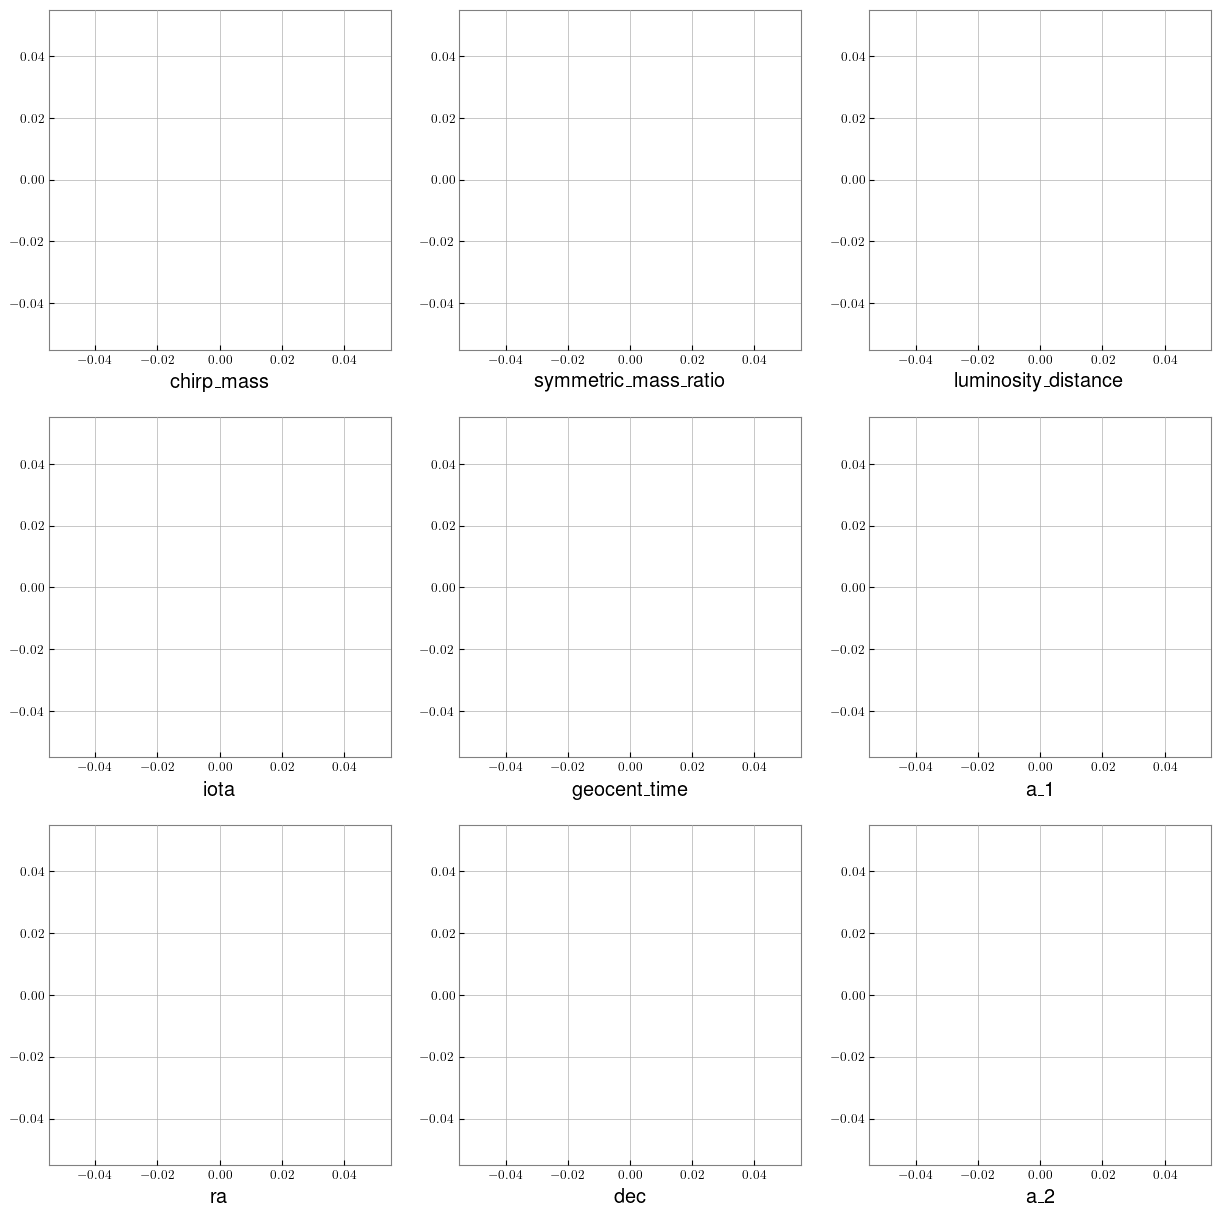

In [65]:
fig, Axes = plt.subplots(3, 3, figsize=(15, 15))

axes = Axes.flatten()

logL_diff = [val[0] - val[1] for val in loop_results.values()]

for ax, key in zip(
    axes,
    ['chirp_mass', 'symmetric_mass_ratio', 'luminosity_distance', 'iota', 'geocent_time', 'a_1', 'ra', 'dec', 'a_2']
):
    ax.scatter([val[2][key] for val in loop_results.values()], logL_diff, s=5, alpha=0.9)
    ax.set_xlabel(key)


In [66]:
fig, axes = plt.subplots(1, 2, figsize=(3.4 * 2.1, 3.4), sharey=True)

logL_bilby = np.array([val[0] for val in loop_results.values()])
logL_jim = np.array([val[1] for val in loop_results.values()])
logL_diff = [1 - val[1]/val[0] for val in loop_results.values()]

axes[0].scatter(np.abs(logL_bilby), logL_diff, s=5, alpha=0.9)
axes[1].scatter(np.abs(logL_jim), logL_diff, s=5, alpha=0.9)
for ax in axes:
    ax.set_xscale('log')
    # ax.set_yscale('log')
    ax.set_ylim(-0.5, 0.5)

axes[0].set_ylabel(r'$1 - \ln{\cal L}_{\rm Jim} / \ln{\cal L}_{\rm Bilby}$')
axes[0].set_xlabel(r'$\vert\ln{\cal L}_{\rm Bilby}\vert$')
axes[1].set_xlabel(r'$\vert\ln{\cal L}_{\rm Jim}\vert$')

Text(0.5, 0, '$\\vert\\ln{\\cal L}_{\\rm Jim}\\vert$')

Error in callback <function _draw_all_if_interactive at 0x7fc0889f5360> (for post_execute), with arguments args (),kwargs {}:


ValueError: Data has no positive values, and therefore cannot be log-scaled.

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 714x340 with 2 Axes>

Text(0, 0.5, '$\\vert\\ln{\\cal L}_{\\rm Jim}\\vert$')

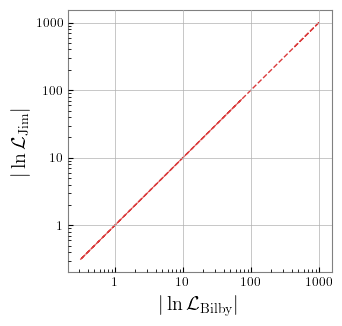

In [67]:
fig, ax = plt.subplots(1, 1, figsize=(3.4, 3.4))

ax.plot(np.abs(logL_bilby), np.abs(logL_bilby), ls='--', alpha=0.9, c='C3')

ax.scatter(np.abs(logL_bilby), np.abs(logL_jim), 
           c=np.abs(logL_diff), s=5, alpha=0.9)
# axes[1].scatter(, np.abs(logL_diff), s=5, alpha=0.9)
ax.set_xscale('log')
ax.set_yscale('log')

# ax.set_ylabel(r'$\vert\ln{\cal L}_{\rm Bilby} - \ln{\cal L}_{\rm Jim}\vert$')
ax.set_xlabel(r'$\vert\ln{\cal L}_{\rm Bilby}\vert$')
ax.set_ylabel(r'$\vert\ln{\cal L}_{\rm Jim}\vert$')

## Check projected detector strain

In [70]:
# Compute Jim detector strain

freqs = jim_likelihood.frequencies
waveform_sky = jim_likelihood.waveform(freqs, jim_params)
align_time = jnp.exp(
    -1j * 2 * jnp.pi * freqs * (jim_likelihood.epoch + jim_params["t_c"])
)

H1_strain = H1.fd_response(freqs, waveform_sky, jim_params) * align_time
L1_strain = L1.fd_response(freqs, waveform_sky, jim_params) * align_time

In [72]:
bilby_waveform_generator.parameters = bilby_params
bilby_hphc = bilby_waveform_generator.frequency_domain_strain()

bilby_H1_strain = ifo_list[0].get_detector_response(bilby_hphc, bilby_params)
bilby_L1_strain = ifo_list[1].get_detector_response(bilby_hphc, bilby_params)

(30, 400)

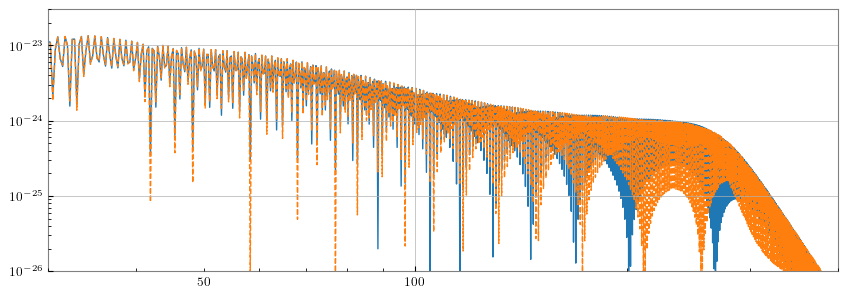

In [99]:
fig, ax = plt.subplots(1, 1, figsize=(3.4*3, 3.4))

ax.loglog(freqs, np.abs(np.real(H1_strain)))
ax.loglog(freqs, np.abs(np.real(bilby_H1_strain)), ls='--')
ax.set_ylim(1e-26, 3e-23)
ax.set_xlim(30, 400)

In [ ]:


# freq_mask = ifo_list[0].frequency_mask

# print(match(H1_strain, bilby_H1_strain, 1/duration, freq_mask))
# print(match(H1_strain, H1_strain, 1/duration, freq_mask))

# print(match(L1_strain, bilby_L1_strain, 1/duration, freq_mask))
# print(match(L1_strain, L1_strain, 1/duration, freq_mask))

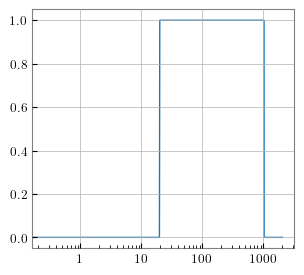

In [ ]:
plt.semilogx(ifo_list[0].frequency_array, ifo_list[0].strain_data.frequency_mask)

In [10]:
def inner_product(a, b, delta_f, psd, mask=None):
    if mask is not None:
        a = a * mask
        b = b * mask
    return 4 * np.real(jnp.sum(a * jnp.conj(b) / psd)) * delta_f

def match(a, b, delta_f, psd, mask):
    ab = inner_product(a, b, delta_f, psd, mask)
    aa = inner_product(a, a, delta_f, psd, mask)
    bb = inner_product(b, b, delta_f, psd, mask)
    return ab / jnp.sqrt(aa * bb)

def compute_jim_likelihood(
    projected_strain, jim_ifo, delta_f
):
    mask = ~jnp.isnan(projected_strain)
    mask = mask & (jim_ifo.frequencies > 20) & (jim_ifo.frequencies < 1000)
    projected_strain = projected_strain[mask]
    jim_data = jim_ifo.data[mask]
    jim_psd = jim_ifo.psd[mask]

    log_likelihood = 0
    match_filter_SNR = (
        4 * jnp.sum((jnp.conj(projected_strain) * jim_data) / jim_psd * delta_f).real
    )
    optimal_SNR = 4 * jnp.sum(jnp.conj(projected_strain) * projected_strain / jim_psd * delta_f).real
    log_likelihood += match_filter_SNR - optimal_SNR / 2

    print(match_filter_SNR, optimal_SNR)

    return log_likelihood


In [113]:
## Refine jim FD response

def fd_response(
    self,
    frequency,
    h_sky,
    params,
):
    """
    Modulate the waveform in the sky frame by the detector response in the frequency domain.
    """
    ra, dec, psi, geocent_time = params["ra"], params["dec"], params["psi"], params["geocent_time"]
    gmst = Time(geocent_time, format="gps").sidereal_time("apparent", "greenwich").rad

    ifo_idx = 0 if self.name == 'H1' else 1
    antenna_pattern = {
        'p': ifo_list[ifo_idx].antenna_response(ra, dec, geocent_time, psi, 'plus'),
        'c': ifo_list[ifo_idx].antenna_response(ra, dec, geocent_time, psi, 'cross'),
    }

    # antenna_pattern = self.antenna_pattern(ra, dec, psi, gmst)
    timeshift = self.delay_from_geocenter(ra, dec, gmst)
    h_detector = jax.tree_util.tree_map(
        lambda h, antenna: h
        * antenna
        * jnp.exp(-2j * jnp.pi * frequency * timeshift),
        h_sky,
        antenna_pattern,
    )
    return jnp.sum(jnp.stack(jax.tree_util.tree_leaves(h_detector)), axis=0)


## Refine jim FD response

def fd_response_2(
    self,
    frequency,
    h_sky,
    params,
):
    """
    Modulate the waveform in the sky frame by the detector response in the frequency domain.
    """
    ra, dec, psi, geocent_time = params["ra"], params["dec"], params["psi"], params["geocent_time"]
    mask = params['freq_mask']
    gmst = Time(geocent_time, format="gps").sidereal_time("apparent", "greenwich").rad


    # antenna_pattern = self.antenna_pattern(ra, dec, psi, gmst)
    # timeshift = self.delay_from_geocenter(ra, dec, gmst)
    ifo_idx = 0 if self.name == 'H1' else 1
    antenna_pattern = {
        'p': ifo_list[ifo_idx].antenna_response(ra, dec, geocent_time, psi, 'plus'),
        'c': ifo_list[ifo_idx].antenna_response(ra, dec, geocent_time, psi, 'cross'),
    }
    timeshift = ifo_list[ifo_idx].time_delay_from_geocenter(ra, dec, geocent_time)
    # timeshift += 2. + params['t_c']
    timeshift += params['geocent_time'] - ifo_list[ifo_idx].strain_data.start_time

    signal_ifo = 0. + 0.j
    for mode in 'pc':
        signal_ifo += h_sky[mode] * antenna_pattern[mode]

    print(mask)
    signal_ifo = jnp.place(signal_ifo, mask, signal_ifo[mask] * jnp.exp(-2j * jnp.pi * frequency[mask] * timeshift), inplace=False)

    # h_detector = jax.tree_util.tree_map(
    #     lambda h, antenna: h
    #     * antenna
    #     * jnp.exp(-2j * jnp.pi * frequency * timeshift),
    #     h_sky,
    #     antenna_pattern,
    # )
    return signal_ifo

In [110]:
jim_params['geocent_time'] - ifo_list[0].strain_data.start_time, 2. + jim_params['t_c']

(np.float64(1.8704369068145752), 1.8703391551971436)

In [94]:
np.all(ifo_list[1].calibration_model.get_calibration_factor(
            freqs, prefix='recalib_{}_'.format('L1'), **bilby_params
        ) == 1)

np.True_

In [114]:
loop_match_results = {}
for trial in range(10):
    not_accept = True
    while not_accept:
        params = priors.sample()
        params = {key: float(val) for key, val in params.items()}
        bilby_params = jim_to_bilby_params(params)
        not_accept = bilby_params['a_1'] > 1 or bilby_params['a_2'] > 1

    bilby_likelihood.parameters = bilby_params
    # print(f'Bilby: {bilby_likelihood.log_likelihood_ratio():.3f}')

    params['geocent_time'] -= trigger_time
    jim_params = {bilby_to_jim_keys_map[key]: params[key] for key in params}
    jim_params['gmst'] = jim_likelihood.gmst
    # print(f'Jim:   {jim_likelihood.evaluate(jim_params, None)}')

    freqs = jim_likelihood.frequencies
    waveform_sky = jim_likelihood.waveform(freqs, jim_params)
    align_time = jnp.exp(
        -1j * 2 * jnp.pi * freqs * (jim_likelihood.epoch + jim_params["t_c"])
    )
    
    bilby_waveform_generator.parameters = bilby_params
    bilby_hphc = bilby_waveform_generator.frequency_domain_strain()

    jim_H1_strain = H1.fd_response(freqs, waveform_sky, jim_params) * align_time
    jim_L1_strain = L1.fd_response(freqs, waveform_sky, jim_params) * align_time

    jim_params['geocent_time'] = bilby_params['geocent_time']
    jim_params['freq_mask'] = ifo_list[0].frequency_mask
    jim_H1_strain_alt = fd_response(H1, freqs, waveform_sky, jim_params) * align_time
    jim_L1_strain_alt = fd_response(L1, freqs, waveform_sky, jim_params) * align_time

    jim_H1_strain_alt_2 = fd_response_2(H1, freqs, waveform_sky, jim_params) * ifo_list[0].frequency_mask
    jim_L1_strain_alt_2 = fd_response_2(L1, freqs, waveform_sky, jim_params) * ifo_list[1].frequency_mask

    bilby_in_jim_waveform = {'p': bilby_hphc['plus'], 'c': bilby_hphc['cross']}
    bilby_H1_strain_jim = fd_response_2(H1, freqs, bilby_in_jim_waveform, jim_params) * ifo_list[0].frequency_mask
    bilby_L1_strain_jim = fd_response_2(L1, freqs, bilby_in_jim_waveform, jim_params) * ifo_list[1].frequency_mask

    bilby_H1_strain = ifo_list[0].get_detector_response(bilby_hphc, bilby_params)
    bilby_L1_strain = ifo_list[1].get_detector_response(bilby_hphc, bilby_params)

    jim_waveform_sky = {'plus': np.array(waveform_sky['p']), 'cross': np.array(waveform_sky['c'])}
    jim_H1_strain_bilby = ifo_list[0].get_detector_response(jim_waveform_sky, bilby_params, freqs)
    jim_L1_strain_bilby = ifo_list[1].get_detector_response(jim_waveform_sky, bilby_params, freqs)

    freq_mask = ifo_list[0].frequency_mask

    # loop_match_results[trial] = (
    #     match(jim_H1_strain, bilby_H1_strain, 1/duration, ifo_list[0].power_spectral_density_array, ifo_list[0].frequency_mask),
    #     match(jim_L1_strain, bilby_L1_strain, 1/duration, ifo_list[1].power_spectral_density_array, ifo_list[1].frequency_mask) )
    loop_match_results[trial] = (
        compute_jim_likelihood(bilby_H1_strain, H1, 1/duration),
        compute_jim_likelihood(jim_H1_strain, H1, 1/duration),
        compute_jim_likelihood(jim_H1_strain_alt, H1, 1/duration),
        compute_jim_likelihood(jim_H1_strain_alt_2, H1, 1/duration),
        compute_jim_likelihood(bilby_H1_strain_jim, H1, 1/duration),
        compute_jim_likelihood(jim_H1_strain_bilby, H1, 1/duration),
    )

    # print('Jim strain:', compute_jim_likelihood(jim_H1_strain, H1, 1/duration))
    # print('Bilby strain:', compute_jim_likelihood(bilby_H1_strain, H1, 1/duration))
    # print('-------------------------------------------------')
loop_match_results

[False False False ... False False False]
[False False False ... False False False]
[False False False ... False False False]
[False False False ... False False False]
-16.5247590103985 352.579819258878
-14.708107243862628 352.58055888170435
-14.708843627314984 352.579851527739
-16.54932359624431 352.57985152773904
-16.524759010397084 352.579819258878
-16.54932359624573 352.579851527739
[False False False ... False False False]
[False False False ... False False False]
[False False False ... False False False]
[False False False ... False False False]
-24.972301482108428 457.8300280354163
-26.649161587491072 457.83546764319055
-26.647802785672088 457.8298570779533
-24.952668935441494 457.8298570779533
-24.9723014821148 457.8300280354163
-24.95266893543511 457.8298570779533
[False False False ... False False False]
[False False False ... False False False]
[False False False ... False False False]
[False False False ... False False False]
-2.76076714887221 218.5781400017387
-2.708309108

{0: (Array(-192.81466864, dtype=float64),
  Array(-190.99838668, dtype=float64),
  Array(-190.99876939, dtype=float64),
  Array(-192.83924936, dtype=float64),
  Array(-192.81466864, dtype=float64),
  Array(-192.83924936, dtype=float64)),
 1: (Array(-253.8873155, dtype=float64),
  Array(-255.56689541, dtype=float64),
  Array(-255.56273132, dtype=float64),
  Array(-253.86759747, dtype=float64),
  Array(-253.8873155, dtype=float64),
  Array(-253.86759747, dtype=float64)),
 2: (Array(-112.04983715, dtype=float64),
  Array(-111.99691527, dtype=float64),
  Array(-111.99776153, dtype=float64),
  Array(-112.05069652, dtype=float64),
  Array(-112.04983715, dtype=float64),
  Array(-112.05069652, dtype=float64)),
 3: (Array(-9.0459506, dtype=float64),
  Array(-9.01024566, dtype=float64),
  Array(-9.0095598, dtype=float64),
  Array(-9.04674938, dtype=float64),
  Array(-9.0459506, dtype=float64),
  Array(-9.04674938, dtype=float64)),
 4: (Array(-41.21966972, dtype=float64),
  Array(-41.35673198, dt

So the problem has to do with the projection

## Try to check the antenna pattern

In [18]:
from astropy.time import Time

{'p': Array(0.38706321, dtype=float64), 'c': Array(-0.48976032, dtype=float64)}
[0.3864873638218031, -0.4898800272710451]


Text(0.5, 1.0, '$\\delta = 0.7\\,{\\rm rad},\\ \\psi = 0.9\\,{\\rm rad},\\ t = 123456789.0\\,{\\rm s}$')

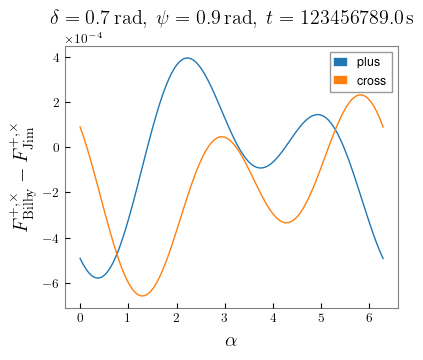

In [50]:
ra = 0.3
dec = 0.7
psi = 0.9
geocent_time = 123456789.0
gmst = Time(geocent_time, format="gps").sidereal_time("apparent", "greenwich").rad
       

print(L1.antenna_pattern(ra, dec, psi, gmst))
print([ifo_list[1].antenna_response(ra, dec, geocent_time, psi, mode) for mode in ['plus', 'cross']])

plus, cross = [], []
for ra in np.linspace(0, 2 * np.pi, 100):
    jim_antenna = L1.antenna_pattern(ra, dec, psi, gmst)
    plus.append((ifo_list[1].antenna_response(ra, dec, geocent_time, psi, 'plus'), jim_antenna['p']))
    cross.append((ifo_list[1].antenna_response(ra, dec, geocent_time, psi, 'cross'), jim_antenna['c']))

fig, ax = plt.subplots(1, 1, figsize=(4.3, 3.4))
ax.plot(
    np.linspace(0, 2 * np.pi, 100), 
    [p[0] - p[1] for p in plus], label='plus'
)

ax.plot(
    np.linspace(0, 2 * np.pi, 100), 
    [p[0] - p[1] for p in cross], label='cross'
)
ax.legend()
ax.set_xlabel(r'$\alpha$')
ax.grid(False)
ax.set_ylabel(r'$F^{+,\times}_{\rm Bilby} - F^{+,\times}_{\rm Jim}$')
ax.set_title(r'$\delta = 0.7\,{\rm rad},\ \psi = 0.9\,{\rm rad},\ t = 123456789.0\,{\rm s}$')

## How about the geocenter time delay

Text(0.5, 1.0, '$t = 123456789.0\\,{\\rm s}$')

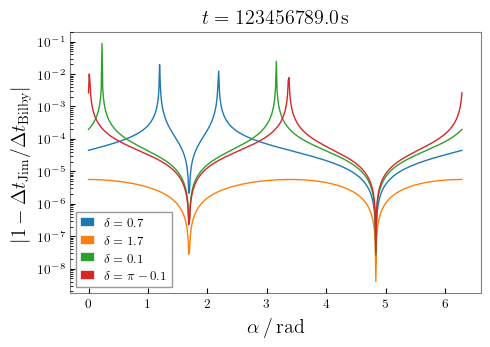

In [65]:
ra = 0.3
dec = 0.7
psi = 0.9
geocent_time = 123456789.0
gmst = Time(geocent_time, format="gps").sidereal_time("apparent", "greenwich").rad

time_delay = []
ras = np.linspace(0, 2 * np.pi, 500)
for ra in ras:
    jim_time_delay = H1.delay_from_geocenter(ra, dec, gmst)
    bilby_time_delay = ifo_list[0].time_delay_from_geocenter(ra, dec, geocent_time)
    time_delay.append((jim_time_delay, bilby_time_delay))

fig, ax = plt.subplots(1, 1, figsize=(5.3, 3.4))
ax.plot(
    ras, 
    [np.abs(1 - p[1]/p[0]) for p in time_delay], label=r'$\delta = 0.7$'
)

dec = 1.7
time_delay = []
ras = np.linspace(0, 2 * np.pi, 500)
for ra in ras:
    jim_time_delay = H1.delay_from_geocenter(ra, dec, gmst)
    bilby_time_delay = ifo_list[0].time_delay_from_geocenter(ra, dec, geocent_time)
    time_delay.append((jim_time_delay, bilby_time_delay))

ax.plot(
    ras, 
    [np.abs(1 - p[1]/p[0]) for p in time_delay], label=r'$\delta = 1.7$'
)

dec = 0.1
time_delay = []
ras = np.linspace(0, 2 * np.pi, 500)
for ra in ras:
    jim_time_delay = H1.delay_from_geocenter(ra, dec, gmst)
    bilby_time_delay = ifo_list[0].time_delay_from_geocenter(ra, dec, geocent_time)
    time_delay.append((jim_time_delay, bilby_time_delay))

ax.plot(
    ras, 
    [np.abs(1 - p[1]/p[0]) for p in time_delay], label=r'$\delta = 0.1$'
)

dec = np.pi - 0.1
time_delay = []
ras = np.linspace(0, 2 * np.pi, 500)
for ra in ras:
    jim_time_delay = H1.delay_from_geocenter(ra, dec, gmst)
    bilby_time_delay = ifo_list[0].time_delay_from_geocenter(ra, dec, geocent_time)
    time_delay.append((jim_time_delay, bilby_time_delay))

ax.plot(
    ras, 
    [np.abs(1 - p[1]/p[0]) for p in time_delay], label=r'$\delta = \pi - 0.1$'
)

ax.legend()
ax.set_yscale('log')
ax.set_xlabel(r'$\alpha\,/\,{\rm rad}$')
ax.grid(False)
ax.set_ylabel(r'$\vert 1 - \Delta t_{\rm Jim} / \Delta t_{\rm Bilby}\vert$')
ax.set_title(r'$t = 123456789.0\,{\rm s}$')

In [52]:
time_delay

[(Array(-0.01125351, dtype=float64), -0.01125400837241111),
 (Array(-0.01054379, dtype=float64), -0.010544293482404297),
 (Array(-0.00983142, dtype=float64), -0.009831926248236637),
 (Array(-0.00911927, dtype=float64), -0.009119775121334566),
 (Array(-0.00841021, dtype=float64), -0.008410707682936808),
 (Array(-0.00770708, dtype=float64), -0.007707579097356856),
 (Array(-0.00701273, dtype=float64), -0.007013220615243976),
 (Array(-0.00632995, dtype=float64), -0.006330428173136158),
 (Array(-0.00566148, dtype=float64), -0.005661951135210423),
 (Array(-0.00501003, dtype=float64), -0.005010481222563693),
 (Array(-0.0043782, dtype=float64), -0.004378641674601941),
 (Array(-0.00376855, dtype=float64), -0.003768976686180994),
 (Array(-0.00318354, dtype=float64), -0.0031839411630317552),
 (Array(-0.00262551, dtype=float64), -0.0026258908367212995),
 (Array(-0.00209671, dtype=float64), -0.0020970727789533087),
 (Array(-0.00159928, dtype=float64), -0.0015996163534033653),
 (Array(-0.00113521, d

(15, 1100)

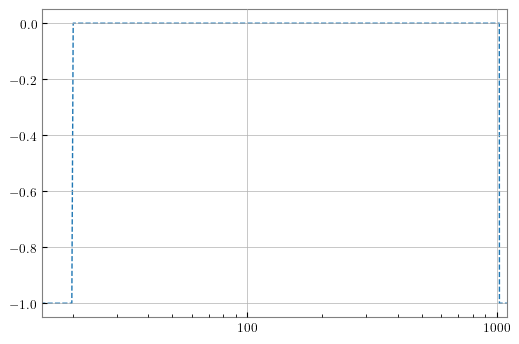

In [40]:
fa = ifo_list[0].frequency_array

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# ax.loglog(fa,)
ax.plot(fa,  - 1 + H1.psd / ifo_list[0].power_spectral_density_array * ifo_list[0].frequency_mask, ls='--')
ax.set_xscale('log')
ax.set_xlim(15, 1100)

In [129]:
all_match = [[*val] for val in loop_match_results.values()]
np.min(all_match), np.max(all_match)

(np.float64(0.9984524360620987), np.float64(0.9998292413893354))

NameError: name 'freqs' is not defined

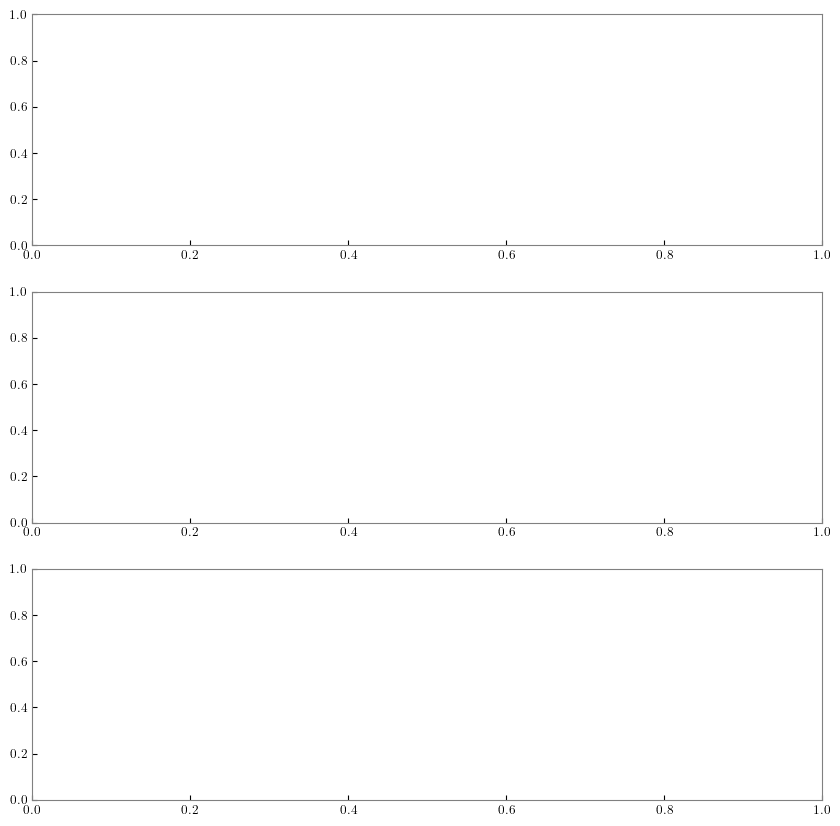

In [1]:
fig, axes = plt.subplots(3, 1, figsize=(3.4*3, 3.4*3))

ax = axes[0]
ax.loglog(freqs, np.abs(jim_H1_strain))
ax.loglog(freqs, np.abs(bilby_H1_strain), ls='--')
ax.set_ylim(1e-26, 3e-23)
ax.set_xlim(30, 400)
ax.set_ylabel(r'H1 strain amplitude, $\vert h(f) \vert$')

ax = axes[1]
ax.loglog(freqs, np.abs(np.real(jim_H1_strain)))
ax.loglog(freqs, np.abs(np.real(bilby_H1_strain)), ls='--')
ax.set_ylim(1e-26, 3e-23)
ax.set_xlim(30, 400)
ax.set_ylabel(r'H1 strain (real), $\vert {\rm Re}[h](f) \vert$')

ax = axes[2]
ax.loglog(freqs, np.abs(np.imag(jim_H1_strain)))
ax.loglog(freqs, np.abs(np.imag(bilby_H1_strain)), ls='--')
ax.set_ylim(1e-26, 3e-23)
ax.set_xlim(30, 400)
ax.set_ylabel(r'H1 strain (imag), $\vert {\rm Im}[h](f) \vert$')

In [115]:
bilby_params

{'chirp_mass': 29.628147604385752,
 'symmetric_mass_ratio': 0.1541293284401973,
 'spin_1x': 0.23069946538871156,
 'spin_1y': -0.4250097628251366,
 'spin_1z': -0.7163547879049537,
 'spin_2x': 0.5984077264847876,
 'spin_2y': -0.6581972773523834,
 'spin_2z': -0.3821130415765206,
 'iota': 1.737751074156212,
 'phase': 5.784390647999561,
 'luminosity_distance': 480.6580901642614,
 'ra': 5.042375010000521,
 'dec': 0.1277334260728765,
 'psi': 2.0397281375577814,
 'geocent_time': 1126259462.4073997,
 'mass_1': np.float64(73.6647744483257),
 'mass_2': np.float64(17.320964776428212),
 'theta_jn': 3.040995532611949,
 'phi_jl': 1.7740430192562993,
 'tilt_1': 2.5477982555303775,
 'tilt_2': 1.9765173088823653,
 'phi_12': 0.24054764268924844,
 'a_1': 0.8643030278679273,
 'a_2': 0.9681558963171387}

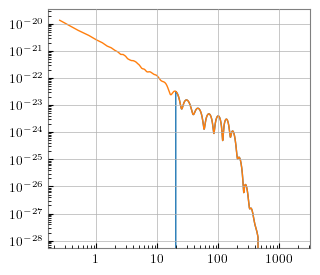

In [119]:
hphc = bilby_waveform_generator.frequency_domain_strain()
jim_hphc = jim_waveform(bilby_waveform_generator.frequency_array, jim_params)

plt.loglog(bilby_waveform_generator.frequency_array, np.abs(hphc['plus']))
plt.loglog(bilby_waveform_generator.frequency_array, np.abs(jim_hphc['p']))

{'p': Array([           nan           +nanj,
        1.34892497e-20-1.11432293e-21j,
        1.82610222e-21+5.46477132e-21j, ...,
        0.00000000e+00+0.00000000e+00j,
        0.00000000e+00+0.00000000e+00j,
        0.00000000e+00+0.00000000e+00j], dtype=complex128),
 'c': Array([            nan           +nanj,
         1.11392370e-21+1.34882804e-20j,
        -5.47304034e-21+1.82492313e-21j, ...,
         0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j], dtype=complex128)}

In [ ]:
def jim_likelihood(
    params, h_sky, detectors, freqs, align_time, **kwargs,
) -> Float:
    log_likelihood = 0.0
    df = freqs[1] - freqs[0]
    for detector in detectors:
        h_dec = detector.fd_response(freqs, h_sky, params) * align_time
        match_filter_SNR = (
            4 * jnp.sum((jnp.conj(h_dec) * detector.data) / detector.psd * df).real
        )
        optimal_SNR = 4 * jnp.sum(jnp.conj(h_dec) * h_dec / detector.psd * df).real
        log_likelihood += match_filter_SNR - optimal_SNR / 2

    return log_likelihood

## Check precision

In [1]:
import math

In [22]:
trigger_time = 1126259462.4
geocent_time = trigger_time + 0.367832
dt = trigger_time - geocent_time
start_time = ifo_list[0].strain_data.start_time

print(
    math.frexp(start_time),
    math.frexp(geocent_time - 2.),
    math.frexp(trigger_time),
    math.frexp(geocent_time - start_time),
    math.frexp(2 - dt)
)


print(geocent_time - start_time, 2 - dt)

(0.5244554301723383, 31) (0.5244554303436689, 31) (0.5244554311037064, 31) (0.5919824242591858, 2) (0.5919579863548279, 2)
2.367929697036743 2.3678319454193115


In [20]:
1 / sampling_frequency

0.00048828125

In [24]:
start_time, trigger_time - 2

(np.float64(1126259460.3999023), 1126259460.4)

Okay, this has nothing to do with precision.

## Look at `gwpy` TimeSeries fetch_open_data

No need to check any outputs, look at the comments in the code:

```python
# if event dataset, pick shortest file that covers the request
    # -- this is a bit hacky, and presumes that only an event dataset
    # -- would be produced with overlapping files.
    # -- This should probably be improved to use dataset information
    if len(cache) and _overlapping(cache):
        cache.sort(key=lambda x: abs(file_segment(x)))
        for url in cache:
            a, b = file_segment(url)
            if a <= start and b >= end:
                cache = [url]
                break
```
from [`gwpy.timeseries.io.losc.py`](https://github.com/gwpy/gwpy/blob/55c4155658db431b234d0f3171ed012aaffca9c8/gwpy/timeseries/io/losc.py#L159-L169).

Basically, the duration of strain data obtain from GWOSC will always be longer than what one asks for (it could be the same at some rare occasions). So, since `Bilby` subtracts the `strain_data.start_time` from the actual `geocent_time`, it can better reflects the length and arrival time of the data. 

For this, one needs to check two things:
1. How `Jim` reads in data, make sure this does not happen.
2. For the test, set the epoch to `trigger_time - strain_data.start_time`


## Test pickle load

In [6]:
import pickle

with open('bilby_runs/outdir/GW150914/GW150914_data0_1126259462-391_generation_data_dump.pickle', 'rb') as pickled_data:
    bilby_gen_data = pickle.load(pickled_data)

bilby_gen_data.interferometers[0].strain_data.start_time, bilby_gen_data.interferometers[1].strain_data.start_time

(np.float64(1126259460.3908691), np.float64(1126259460.3908691))

In [7]:
bilby_gen_data.__dict__

{'trigger_time': 1126259462.391,
 'label': 'GW150914_data0_1126259462-391_generation',
 'outdir': 'outdir/GW150914/data',
 'interferometers': [Interferometer(name='H1', power_spectral_density=PowerSpectralDensity(psd_file='/home/thomas.ng/project/jim_GWTC3/bilby_runs/psd/GW150914_psd_H1.dat', asd_file='None'), minimum_frequency=20.0, maximum_frequency=896.0, length=4.0, latitude=46.45514666666667, longitude=-119.4076571388889, elevation=142.554, xarm_azimuth=125.9994, yarm_azimuth=215.9994, xarm_tilt=-0.0006195, yarm_tilt=1.25e-05),
  Interferometer(name='L1', power_spectral_density=PowerSpectralDensity(psd_file='/home/thomas.ng/project/jim_GWTC3/bilby_runs/psd/GW150914_psd_L1.dat', asd_file='None'), minimum_frequency=20.0, maximum_frequency=896.0, length=4.0, latitude=30.562894333333332, longitude=-90.77424038888887, elevation=-6.574, xarm_azimuth=197.7165, yarm_azimuth=287.7165, xarm_tilt=-0.0003121, yarm_tilt=-0.0006107)],
 'likelihood_lookup_table': None,
 'likelihood_roq_weights':

In [9]:
bilby_gen_data.interferometers[0].power_spectral_density_array

array([5.00000e-01, 5.00000e-01, 5.00000e-01, ..., 8.07218e-47,
       1.18721e-44,         inf])

In [11]:
bilby_gen_data.interferometers[0].strain_data.time_array[-1] == \
    bilby_gen_data.interferometers[0].strain_data.start_time + \
    bilby_gen_data.interferometers[0].strain_data.duration

np.False_

In [18]:
strain_end_time = bilby_gen_data.interferometers[0].strain_data.time_array[-1]

In [19]:
end_time = bilby_gen_data.interferometers[0].strain_data.start_time + \
    bilby_gen_data.interferometers[0].strain_data.duration

In [17]:
bilby_gen_data.interferometers[0].strain_data.time_array[0] == \
    bilby_gen_data.interferometers[0].strain_data.start_time

np.True_

In [20]:
strain_end_time - end_time

np.float64(-0.00048828125)

## Plot results

In [ ]:
import matplotlib.pyplot as plt

Text(0.5, 0.98, 'GW150914')

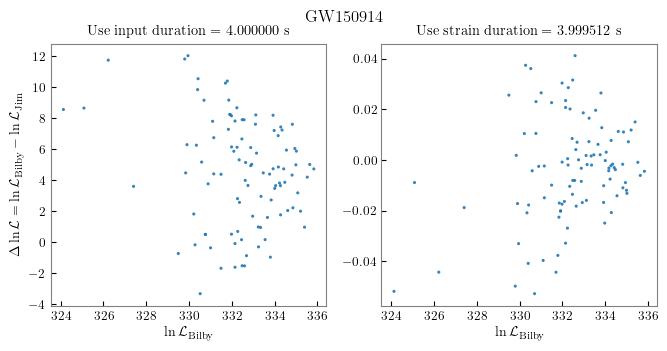

In [28]:
duration = 4.000000
strain_duration = 3.999512

diff_logLs = np.load("compare_GW150914_likelihoods.npy")

fig, axes = plt.subplots(1, 2, figsize=(3.4 * 2.3, 3.4))

logL_diff_1 = diff_logLs['logL_bilby'] - diff_logLs['logL_jim_1']
logL_diff_2 = diff_logLs['logL_bilby'] - diff_logLs['logL_jim_2']

ax = axes[0]
ax.scatter(
    diff_logLs['logL_bilby'], logL_diff_1, s=5, alpha=0.9
)
ax.set_title(f'Use input duration = {duration:.6f} s')
ax.set_ylabel(r'$ \Delta \ln {\cal L} = \ln {\cal L}_{\rm Bilby} - \ln {\cal L}_{\rm Jim}$')

ax = axes[1]
ax.scatter(
    diff_logLs['logL_bilby'], logL_diff_2, s=5, alpha=0.9
)
ax.set_title(f'Use strain duration = {strain_duration:.6f} s')

for ax in axes:
    ax.set_xlabel(r'$\ln {\cal L}_{\rm Bilby}$')

fig.suptitle('GW150914')

## Check effects of marginalisation

In [71]:
from pathlib import Path
import pickle

from bilby.gw.result import CBCResult
from bilby.gw import WaveformGenerator, GravitationalWaveTransient
from bilby.gw.source import lal_binary_black_hole

## We load in the pickle dump from the bilby run
indir = Path('/home/thomas.ng/project/jim_GWTC3/bilby_runs/outdir/GW150914')
with open(indir / 'data/GW150914_data0_1126259462-391_generation_data_dump.pickle', 'rb') as pickled_data:
    bilby_gen_data = pickle.load(pickled_data)

bilby_result = CBCResult.from_hdf5(
    indir / 'final_result/GW150914_data0_1126259462-391_analysis_H1L1_result.hdf5'
)
bilby_poste = bilby_result.posterior
bilby_prior = bilby_result.priors
bilby_ifos = bilby_gen_data.interferometers
likelihood_kwargs = bilby_result.meta_data['likelihood']

In [76]:
sampling_frequency = float(bilby_gen_data.meta_data['command_line_args']['sampling_frequency'])
reference_frequency = float(bilby_gen_data.meta_data['command_line_args']['reference_frequency'])
trigger_time = bilby_gen_data.trigger_time
# Input duration
duration = float(bilby_gen_data.meta_data['command_line_args']['duration'])
post_trigger_duration = float(bilby_gen_data.meta_data['command_line_args']['post_trigger_duration'])
start_time = trigger_time + post_trigger_duration - duration
print(f"{duration = :.6f}")
# Precise duration of the strain data
strain_start_time = bilby_ifos[0].strain_data.start_time
strain_end_time = bilby_ifos[0].strain_data.time_array[-1]
strain_duration = strain_end_time - strain_start_time
strain_post_trigger_duration = strain_end_time - trigger_time
print(f"{strain_duration = :.6f}")

## Reconstruct Bilby waveform generator
bilby_waveform_generator = WaveformGenerator(
    duration=duration,
    sampling_frequency=sampling_frequency,
    start_time=start_time,
    frequency_domain_source_model=lal_binary_black_hole,
    waveform_arguments=dict(
        waveform_approximant="IMRPhenomPv2",
        reference_frequency=20,
        minimum_frequency=20,
    )
)

## Reconstruct Bilby likelihood
likelihood_bilby = GravitationalWaveTransient(
    interferometers=bilby_ifos,
    waveform_generator=bilby_waveform_generator,
    time_marginalization=False,
    jitter_time=False,
    priors=bilby_prior.copy(),
    reference_frame=likelihood_kwargs['reference_frame'],
)

likelihood_bilby_time_marg = GravitationalWaveTransient(
    interferometers=bilby_ifos,
    waveform_generator=bilby_waveform_generator,
    time_marginalization=True,
    jitter_time=True,
    priors=bilby_prior.copy(),
    reference_frame=likelihood_kwargs['reference_frame'],
)


23:36 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


duration = 4.000000
strain_duration = 3.999512


In [13]:
n_samples = 100
samples_bilby = bilby_poste.sample(n_samples, random_state=42)

likelihood_bilby.parameters = samples_bilby.iloc[0].to_dict()
print(likelihood_bilby.log_likelihood_ratio())
likelihood_bilby_time_marg.parameters = samples_bilby.iloc[0].to_dict()
print(likelihood_bilby_time_marg.log_likelihood_ratio())

/cvmfs/software.igwn.org/conda/envs/igwn-py311/lib/python3.11/site-packages/bilby/gw/source.py:528: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


330.2242481706973
-293.7559690949414


In [18]:
samples_bilby['H1_log_likelihood']

530     212.524274
5003    215.755815
4987    215.845885
1340    215.248735
4868    214.381085
           ...    
3475    214.705776
4617    215.380349
1890    211.660061
65      212.699770
4420    216.309468
Name: H1_log_likelihood, Length: 100, dtype: float64

In [17]:
print(bilby_result.log_likelihood_evaluations)

None


In [51]:

bilby_result.meta_data['likelihood']

{'calibration_marginalization': False,
 'distance_marginalization': False,
 'duration': 4.0,
 'frequency_domain_source_model': <function bilby.gw.source.lal_binary_black_hole(frequency_array, mass_1, mass_2, luminosity_distance, a_1, tilt_1, phi_12, a_2, tilt_2, phi_jl, theta_jn, phase, **kwargs)>,
 'lal_version': 'lal_version=7.3.0, lal_git_version=Branch: None;Tag: lal-v7.3.0;Id: 161cede25dff699b3aa4611ef4e2263e8fb2b4fb;;Builder: Adam Mercer <adam.mercer@ligo.org>;Repository status: CLEAN: All modifications committed',
 'lalsimulation_version': 'lalsimulation_version=5.0.0, lalsimulation_git_version=Branch: None;Tag: lalsimulation-v5.0.0;Id: ea7b526f83361e7b276be984b1415af76778d841;;Builder: Adam Mercer <adam.mercer@ligo.org>;Repository status: CLEAN: All modifications committed',
 'parameter_conversion': <function bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters(parameters)>,
 'phase_marginalization': False,
 'reference_frame': 'H1L1',
 'sampling_frequency': 2048.0,
 

In [21]:
samples_bilby.keys()

Index(['H1_log_likelihood', 'H1_matched_filter_snr', 'H1_optimal_snr',
       'L1_log_likelihood', 'L1_matched_filter_snr', 'L1_optimal_snr', 'a_1',
       'a_2', 'azimuth', 'chi_1_in_plane', 'chi_2_in_plane', 'chi_eff',
       'chi_p', 'chirp_mass', 'chirp_mass_source', 'comoving_distance',
       'cos_tilt_1', 'cos_tilt_2', 'dec', 'geocent_time', 'iota',
       'log_likelihood', 'log_prior', 'luminosity_distance', 'mass_1',
       'mass_1_source', 'mass_2', 'mass_2_source', 'mass_ratio',
       'minimum_frequency', 'phase', 'phi_1', 'phi_12', 'phi_2', 'phi_jl',
       'psi', 'ra', 'redshift', 'reference_frequency', 'spin_1x', 'spin_1y',
       'spin_1z', 'spin_2x', 'spin_2y', 'spin_2z', 'symmetric_mass_ratio',
       'theta_jn', 'tilt_1', 'tilt_2', 'time_jitter', 'total_mass',
       'total_mass_source', 'waveform_approximant', 'zenith'],
      dtype='object')

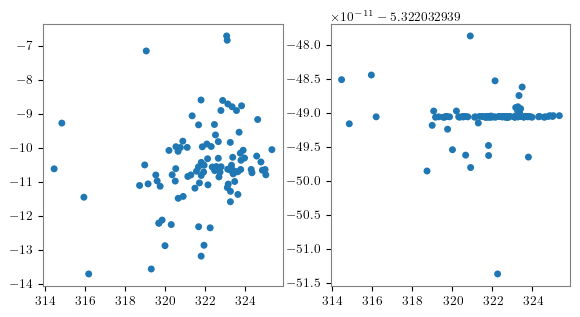

In [28]:
kappa_sq = samples_bilby['H1_matched_filter_snr'].to_numpy().real * samples_bilby['H1_optimal_snr']
H1_logL = kappa_sq - 0.5 * samples_bilby['H1_optimal_snr'] ** 2
# print(H1_logL, samples_bilby['H1_log_likelihood'])

kappa_sq = samples_bilby['L1_matched_filter_snr'].to_numpy().real * samples_bilby['L1_optimal_snr']
L1_logL = kappa_sq - 0.5 * samples_bilby['L1_optimal_snr'] ** 2
# print(L1_logL, samples_bilby['L1_log_likelihood'])

samples_logL = samples_bilby['H1_log_likelihood'] + samples_bilby['L1_log_likelihood']
HL_logL = H1_logL + L1_logL

fig, axes = plt.subplots(1, 2, figsize=(3.4*2, 3.4))
axes[0].scatter(samples_logL, samples_logL - HL_logL)
axes[1].scatter(samples_logL, samples_logL - samples_bilby['log_likelihood'])

In [44]:
def compare_marginalised(marginalized, non_marginalized, key, prior, values=None):
    if values is None:
        values = np.linspace(prior.minimum, prior.maximum, 1000)
    prior_values = prior.prob(values)
    ln_likes = np.empty(values.shape)
    for ii, value in enumerate(values):
        non_marginalized.parameters[key] = value
        ln_likes[ii] = non_marginalized.log_likelihood_ratio()
    like = np.exp(ln_likes - max(ln_likes))

    marg_like = np.log(np.trapz(like * prior_values, values)) + max(ln_likes)
    print(np.isclose(
        marg_like, marginalized.log_likelihood_ratio()-0.5)
    )
    print(
        marg_like, marginalized.log_likelihood_ratio()-0.5
    )

In [73]:
likelihood_bilby.parameters = samples_bilby.iloc[0].to_dict().copy()
likelihood_bilby_time_marg.parameters = samples_bilby.iloc[0].to_dict().copy()
likelihood_bilby_time_marg.parameters['geocent_time'] = start_time
compare_marginalised(
    likelihood_bilby_time_marg, likelihood_bilby, 
    'geocent_time', bilby_prior['geocent_time']
)

False
323.29488850641883 323.3720819510794


Okay, so in the `compare_GW150914_likelihoods.pdf`, there are six plots.

The first five of them share the same $x$-axis, 
the likelihood values from the `bilby` `time-marginalised` likelihood that we constructed.

In order, these five are subtracting:
1. The Jim likelihood using the input duration
2. The Jim likelihood using the strain duration
3. The `log_likelihood` stores in the posterior
4. The sum of `H1` and `L1` `log_likelihood`s
5. The log likelihood constructed from stored SNRs

For the last plot, it is comparing the 2. and 5. .


In [80]:
idx = 42
print(samples_bilby[['log_likelihood', 'H1_log_likelihood', 'L1_log_likelihood']].iloc[idx])

likelihood_bilby.parameters = samples_bilby.iloc[idx].to_dict().copy()
no_time_marg_computed = likelihood_bilby.compute_per_detector_log_likelihood()
H1_logL = no_time_marg_computed['H1_log_likelihood']
L1_logL = no_time_marg_computed['L1_log_likelihood']
print(H1_logL, L1_logL)
print(likelihood_bilby.log_likelihood_ratio(), H1_logL+L1_logL)

likelihood_bilby_time_marg.parameters = samples_bilby.iloc[idx].to_dict().copy()
likelihood_bilby_time_marg.parameters['geocent_time'] = start_time
time_marg_computed = likelihood_bilby_time_marg.compute_per_detector_log_likelihood()
H1_logL = time_marg_computed['H1_log_likelihood']
L1_logL = time_marg_computed['L1_log_likelihood']
print(H1_logL, L1_logL)
print(likelihood_bilby_time_marg.log_likelihood_ratio(), H1_logL+L1_logL)

log_likelihood       321.510988
H1_log_likelihood    212.541060
L1_log_likelihood    103.647895
Name: 79, dtype: float64
217.41128100810366 112.4938693406504
329.9051503487541 329.9051503487541
207.05779870757993 97.54731932548269
309.92715097232474 304.60511803306264


In [84]:
samples_bilby.keys()

Index(['H1_log_likelihood', 'H1_matched_filter_snr', 'H1_optimal_snr',
       'L1_log_likelihood', 'L1_matched_filter_snr', 'L1_optimal_snr', 'a_1',
       'a_2', 'azimuth', 'chi_1_in_plane', 'chi_2_in_plane', 'chi_eff',
       'chi_p', 'chirp_mass', 'chirp_mass_source', 'comoving_distance',
       'cos_tilt_1', 'cos_tilt_2', 'dec', 'geocent_time', 'iota',
       'log_likelihood', 'log_prior', 'luminosity_distance', 'mass_1',
       'mass_1_source', 'mass_2', 'mass_2_source', 'mass_ratio',
       'minimum_frequency', 'phase', 'phi_1', 'phi_12', 'phi_2', 'phi_jl',
       'psi', 'ra', 'redshift', 'reference_frequency', 'spin_1x', 'spin_1y',
       'spin_1z', 'spin_2x', 'spin_2y', 'spin_2z', 'symmetric_mass_ratio',
       'theta_jn', 'tilt_1', 'tilt_2', 'time_jitter', 'total_mass',
       'total_mass_source', 'waveform_approximant', 'zenith'],
      dtype='object')

H1_log_likelihood    212.524274
L1_log_likelihood    106.631149
Name: 530, dtype: float64

## Read No-time marginalisation results

In [90]:
## We load in the pickle dump from the bilby run
indir = Path('/home/thomas.ng/project/jim_GWTC3/bilby_runs/outdir/GW150914_time')
with open(indir / 'data/GW150914_time_data0_1126259462-391_generation_data_dump.pickle', 'rb') as pickled_data:
    bilby_gen_data = pickle.load(pickled_data)

bilby_result = CBCResult.from_hdf5(
    indir / 'final_result/GW150914_time_data0_1126259462-391_analysis_H1L1_result.hdf5'
)
bilby_poste = bilby_result.posterior
bilby_prior = bilby_result.priors
bilby_ifos = bilby_gen_data.interferometers
likelihood_kwargs = bilby_result.meta_data['likelihood']

n_samples = 100
samples_bilby = bilby_poste.sample(n_samples, random_state=42)

In [91]:
idx = 42
print(samples_bilby[['log_likelihood', 'H1_log_likelihood', 'L1_log_likelihood']].iloc[idx])

likelihood_bilby.parameters = samples_bilby.iloc[idx].to_dict().copy()
no_time_marg_computed = likelihood_bilby.compute_per_detector_log_likelihood()
H1_logL = no_time_marg_computed['H1_log_likelihood']
L1_logL = no_time_marg_computed['L1_log_likelihood']
print(H1_logL, L1_logL)
print(likelihood_bilby.log_likelihood_ratio(), H1_logL+L1_logL)

likelihood_bilby_time_marg.parameters = samples_bilby.iloc[idx].to_dict().copy()
likelihood_bilby_time_marg.parameters['geocent_time'] = start_time
time_marg_computed = likelihood_bilby_time_marg.compute_per_detector_log_likelihood()
H1_logL = time_marg_computed['H1_log_likelihood']
L1_logL = time_marg_computed['L1_log_likelihood']
print(H1_logL, L1_logL)
print(likelihood_bilby_time_marg.log_likelihood_ratio(), H1_logL+L1_logL)

log_likelihood       334.016656
H1_log_likelihood    218.734832
L1_log_likelihood    115.281824
Name: 4105, dtype: float64
218.73483236926046 115.28182388396291
334.01665625322335 334.01665625322335
191.6034351501432 92.69751259007984
289.6229222025204 284.300947740223


## Check LogIt precision requirement

In [1]:
import numpy as np
def logit(p):
    return np.log(p) - np.log(1 - p)

def inv_logit(p):
    return np.exp(p) / (1 + np.exp(p))

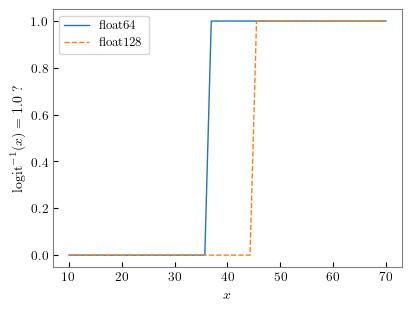

In [22]:
x_array_64 = np.linspace(10, 70, 50, dtype=np.float64)
x_array_128 = np.linspace(10, 70, 50, dtype=np.float128)
fig, ax = plt.subplots(1, 1, figsize=(4, 3),
                       constrained_layout=True)
ax.plot(x_array_64, inv_logit(x_array_64) == np.array([1.0], dtype=np.float64), label='float64')
ax.plot(x_array_128, inv_logit(x_array_128) == np.array([1.0], dtype=np.float128), ls='--', label='float128')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'${\rm logit}^{-1}(x) = 1.0$ ?')
ax.legend()